In [14]:
import pandas as pd
import plotly.express as px
import numpy as np

#Loading dataset - Diabetes study

df= pd.read_csv('../diabetes_012_health_indicators_BRFSS2015.csv')

print("Shape of dataset:", df.shape)
print(df.info)
print(df.head(5))


Shape of dataset: (253680, 22)
<bound method DataFrame.info of         Diabetes_012  HighBP  HighChol  CholCheck   BMI  Smoker  Stroke  \
0                0.0     1.0       1.0        1.0  40.0     1.0     0.0   
1                0.0     0.0       0.0        0.0  25.0     1.0     0.0   
2                0.0     1.0       1.0        1.0  28.0     0.0     0.0   
3                0.0     1.0       0.0        1.0  27.0     0.0     0.0   
4                0.0     1.0       1.0        1.0  24.0     0.0     0.0   
...              ...     ...       ...        ...   ...     ...     ...   
253675           0.0     1.0       1.0        1.0  45.0     0.0     0.0   
253676           2.0     1.0       1.0        1.0  18.0     0.0     0.0   
253677           0.0     0.0       0.0        1.0  28.0     0.0     0.0   
253678           0.0     1.0       0.0        1.0  23.0     0.0     0.0   
253679           2.0     1.0       1.0        1.0  25.0     0.0     0.0   

        HeartDiseaseorAttack  PhysAc

## Data Dictionary (Feature Definitions)

column Diabetes_012
0 = no diabetes
1 = prediabetes
2 = diabetes

### General Health/Conditions
column HighBP
0 = no
1 = yes

column HighChol
0 = no
1 = yes

column CholCheck
0 = no
1 = yes

column Stroke
0 = no
1 = yes

column HeartDiseaseorAttack
0 = no
1 = yes

### Life Style
column Smoker
0 = no
1 = yes

column PhysActivity
0 = no
1 = yes

column Fruits
0 = no
1 = yes

column Veggies
0 = no
1 = yes

column HvyAlcoholConsump
0 = no
1 = yes

### Healthcare Access
column AnyHealthcare
0 = no
1 = yes

column NoDocbcCost
0 = no
1 = yes

### Physical Health Conditions
column DiffWalk
0 = no
1 = yes

### Sex
column Sex
0 = female
1 = male

### Other scales
column GenHlth
1 = excellent
2 = very good
3 = good
4 = fair
5 = poor

column MentHlth  
0–30 = number of days of poor mental health in the past month  

column PhysHlth  
0–30 = number of days of poor physical health in the past month  

column BMI  
numeric value (Body Mass Index)

column Age
1 = 18–24
2 = 25–29
3 = 30–34
4 = 35–39
5 = 40–44
6 = 45–49
7 = 50–54
8 = 55–59
9 = 60–64
10 = 65–69
11 = 70–74
12 = 75–79
13 = 80+


column Education
1 = never attended school
2 = elementary
3 = some high school
4 = high school graduate
5 = some college
6 = college graduate


column Income
1 = < $10k
2 = $10k–$15k
3 = $15k–$20k
4 = $20k–$25k
5 = $25k–$35k
6 = $35k–$50k
7 = $50k–$75k
8 = > $75k






In [15]:
#Analysing by sex (%)
print()

df["Sex"] = df["Sex"].map({0: "female", 1: "male"})
print((df["Sex"].value_counts(normalize=True) * 100).round(2))




Sex
female    55.97
male      44.03
Name: proportion, dtype: float64


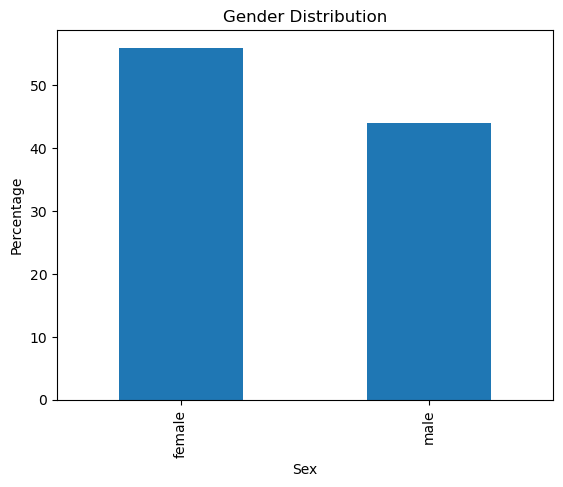

In [16]:
import matplotlib.pyplot as plt

gender_pct = (df["Sex"].value_counts(normalize=True) * 100).round(2)

gender_pct.plot(kind="bar")

plt.title("Gender Distribution")
plt.xlabel("Sex")
plt.ylabel("Percentage")

plt.show()

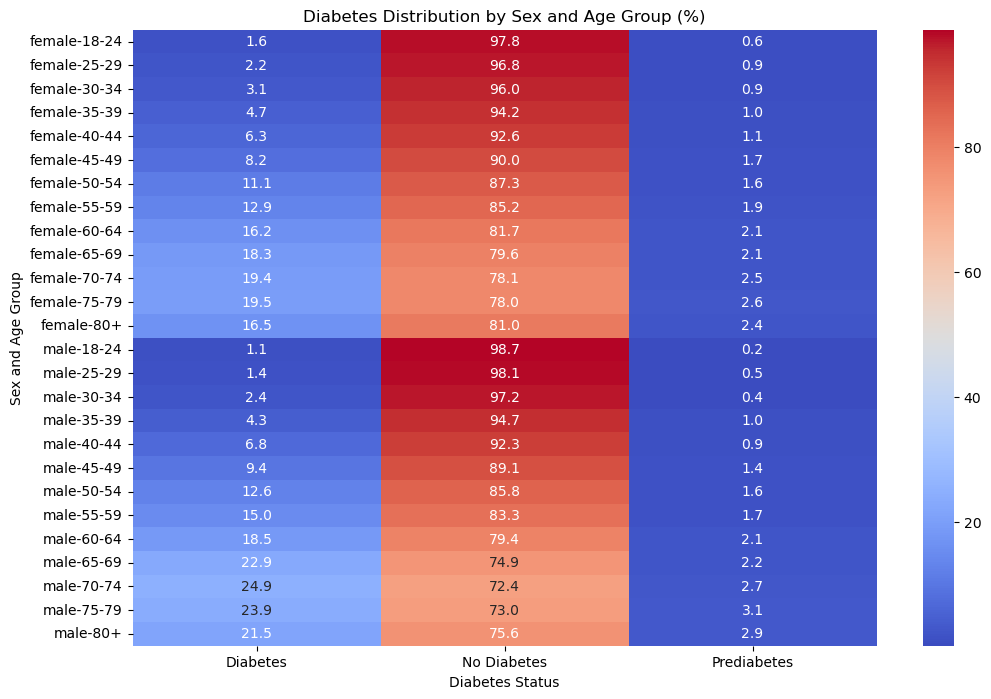

In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Só mapeia se ainda estiver numérico
if df["Sex"].dtype != "object":
    df["Sex"] = df["Sex"].map({0: "female", 1: "male"})

df["Diabetes_Status"] = df["Diabetes_012"].map({
    0: "No Diabetes",
    1: "Prediabetes",
    2: "Diabetes"
})

age_map = {
    1: "18-24", 2: "25-29", 3: "30-34", 4: "35-39",
    5: "40-44", 6: "45-49", 7: "50-54", 8: "55-59",
    9: "60-64", 10: "65-69", 11: "70-74", 12: "75-79", 13: "80+"
}

df["Age_Group"] = df["Age"].map(age_map)

df_clean = df.dropna(subset=["Sex", "Age_Group", "Diabetes_Status"])

table = pd.crosstab(
    [df_clean["Sex"], df_clean["Age_Group"]],
    df_clean["Diabetes_Status"],
    normalize="index"
) * 100

table = table.round(2)

plt.figure(figsize=(12, 8))

sns.heatmap(
    table,
    annot=True,
    fmt=".1f",
    cmap="coolwarm"
)

plt.title("Diabetes Distribution by Sex and Age Group (%)")
plt.xlabel("Diabetes Status")
plt.ylabel("Sex and Age Group")

plt.show()


In [18]:
#Analyzing the impact of lifestyle habits on diabetes risk
print()

df["healthy_score"] = (
    df["PhysActivity"] +
    df["Fruits"] +
    df["Veggies"] +
    (1 - df["Smoker"])
)

(pd.crosstab(df["healthy_score"], df["Diabetes_012"], normalize="index") * 100).round(2)



Diabetes_012,0.0,1.0,2.0
healthy_score,,,
0.0,75.02,2.57,22.41
1.0,77.00,2.38,20.62
2.0,80.63,2.12,17.25
3.0,85.08,1.77,13.15
4.0,89.75,1.38,8.88


The healthy_score represents the number of healthy lifestyle habits adopted by an individual, ranging from 0 (no healthy habits) to 4 (all considered healthy habits). These habits include physical activity, fruit consumption, vegetable consumption, and non-smoking behavior.

The analysis reveals a clear and consistent pattern: as the healthy_score increases, the prevalence of diabetes significantly decreases. Individuals with a score of 0 show a diabetes rate of approximately 22.4%, while those with the highest score (4) have a much lower rate, around 8.9%.

At the same time, the proportion of individuals without diabetes increases steadily as the healthy_score rises. This suggests a strong association between healthier daily habits and better health outcomes.

Overall, the results indicate that adopting multiple healthy lifestyle behaviors is strongly linked to a reduced risk of diabetes, highlighting the importance of preventive health practices.


In [19]:
from sklearn.linear_model import LogisticRegression

X = df[["PhysActivity", "Fruits", "Veggies", "Smoker"]]
y = df["Diabetes_012"] == 2  # diabetes vs not

model = LogisticRegression()
model.fit(X, y)

print(model.coef_)



[[-0.63693256 -0.07259222 -0.24363493  0.28919805]]


PhysActivity (-0.637): strongest negative effect
→ Physical activity is the most protective factor, significantly reducing diabetes risk
Veggies (-0.244): moderate protective effect
→ Vegetable consumption is associated with lower diabetes risk
Fruits (-0.073): weak effect
→ Fruit consumption has a small protective impact
Smoker (+0.289):increases risk
→ Smoking is associated with a higher likelihood of diabetes

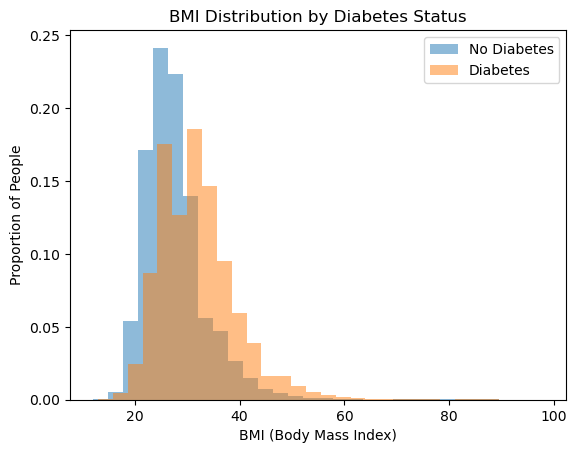

In [20]:
import matplotlib.pyplot as plt


plt.hist(
    df[df["Diabetes_012"] == 0]["BMI"],
    bins=30,
    alpha=0.5,
    label="No Diabetes",
    weights=[1/len(df[df["Diabetes_012"] == 0])] * len(df[df["Diabetes_012"] == 0])
)

plt.hist(
    df[df["Diabetes_012"] == 2]["BMI"],
    bins=30,
    alpha=0.5,
    label="Diabetes",
    weights=[1/len(df[df["Diabetes_012"] == 2])] * len(df[df["Diabetes_012"] == 2])
)

plt.legend()
plt.xlabel("BMI (Body Mass Index)")
plt.ylabel("Proportion of People")
plt.title("BMI Distribution by Diabetes Status")

plt.show()

In [21]:
(df["Diabetes_012"].value_counts(normalize=True) * 100).round(2)

Diabetes_012
0.0    84.24
2.0    13.93
1.0     1.83
Name: proportion, dtype: float64

The chart shows the overall distribution of diabetes status in the dataset. The majority of individuals, approximately 85%, do not have diabetes. A smaller portion, around 13%, are classified as diabetic, while only about 2% fall into the prediabetes category.

This imbalance indicates that the dataset is heavily skewed toward non-diabetic individuals. As a result, any analysis or predictive modeling should take this class imbalance into account, as it may affect model performance and interpretation.

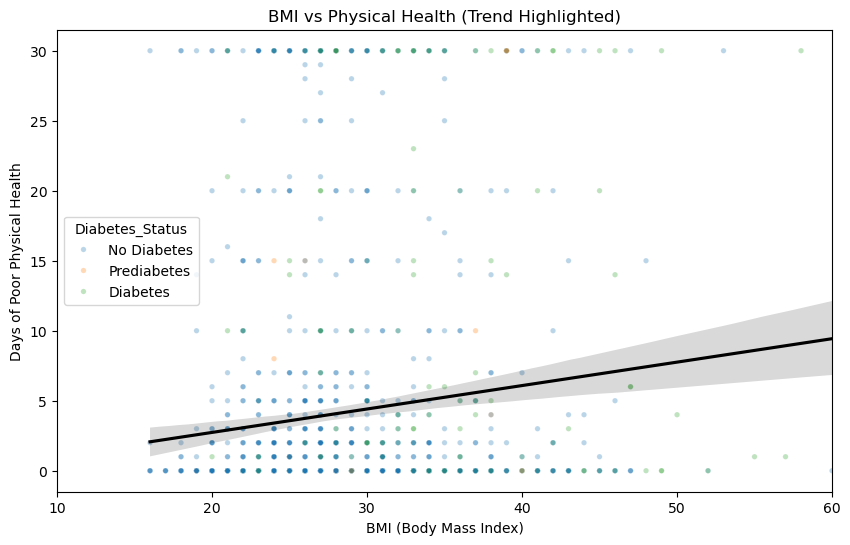

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

sample_df = df.sample(1500, random_state=42).copy()

sample_df["Diabetes_Status"] = sample_df["Diabetes_012"].map({
    0: "No Diabetes",
    1: "Prediabetes",
    2: "Diabetes"
})

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=sample_df,
    x="BMI",
    y="PhysHlth",
    hue="Diabetes_Status",
    alpha=0.3,
    s=15
)

# 👇 linha de tendência (isso muda o jogo)
sns.regplot(
    data=sample_df,
    x="BMI",
    y="PhysHlth",
    scatter=False,
    color="black"
)

plt.title("BMI vs Physical Health (Trend Highlighted)")
plt.xlabel("BMI (Body Mass Index)")
plt.ylabel("Days of Poor Physical Health")

plt.xlim(10, 60)

plt.show()

The scatter plot explores the relationship between Body Mass Index (BMI) and the number of days of poor physical health, with individuals categorized by diabetes status.

Despite some variability in the data, a general upward trend can be observed: as BMI increases, the number of days of poor physical health tends to rise. This pattern suggests that higher body weight is associated with worse physical health outcomes.

Additionally, individuals with diabetes appear more frequently in regions of higher BMI and increased physical health issues, reinforcing the idea that excess body weight is a key risk factor linked to both poor health and diabetes.

Overall, this analysis highlights a consistent relationship between BMI and physical well-being, supporting the broader conclusion that maintaining a healthy body weight is an important factor in reducing both physical health problems and the risk of diabetes.

## Conclusion:
The analysis of this dataset reveals several important patterns regarding the relationship between lifestyle, demographic factors, and diabetes prevalence.

First, lifestyle behaviors play a significant role in diabetes risk. Individuals with healthier habits — such as engaging in physical activity, consuming fruits and vegetables, and avoiding smoking — show a notably lower prevalence of diabetes. Among these factors, physical activity stands out as the most influential protective behavior.

Second, body weight, measured through BMI, is strongly associated with both diabetes and overall physical health. Higher BMI values are linked to an increased number of days of poor physical health, and individuals with diabetes are more frequently observed within higher BMI ranges. This reinforces the role of obesity as a key risk factor.

Additionally, age emerges as a critical determinant. The prevalence of diabetes increases consistently across age groups, indicating that risk accumulates over time. When combined with gender, the data suggests that both males and females follow similar trends, although slight differences may exist in specific age ranges.

Finally, the dataset shows a class imbalance, with the majority of individuals classified as non-diabetic. This highlights the importance of careful interpretation and consideration when building predictive models.

Overall, the findings emphasize that diabetes is influenced by a combination of lifestyle choices, physical health conditions, and demographic factors. Promoting healthier behaviors and maintaining a healthy body weight appear to be key strategies in reducing the risk of diabetes.